# Predicting Irrigation Need: Bagging Model
Lucas Calaff 
04/14/26

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

## 1. Data Importing and Cleaning 

In [38]:
IR_Train = pd.read_csv("Advanced_ML_Work/Git_Code/Kaggle Homework Lucas lucascalaff206/train.csv")

IR_Train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [39]:
# dropping id column and finding all categorical features
IR_Train = IR_Train.drop("id", axis=1)

In [46]:
# pre modeling steps

y = IR_Train["Irrigation_Need"]
X = IR_Train.drop(columns=["Irrigation_Need"])
X_encoded = pd.get_dummies(X, drop_first=True).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

## 2. Base Random Forest Model 

In [53]:
# Initail Random Forest Model with no tuning 
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

confusion_matrix(y_test, y_pred_rf)

array([[ 3749,     0,   500],
       [    0, 73440,   297],
       [   89,  1013, 46912]])

In [54]:
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.9849285714285714
              precision    recall  f1-score   support

        High       0.98      0.88      0.93      4249
         Low       0.99      1.00      0.99     73737
      Medium       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.98      0.98      0.98    126000



Looking at the initial model we can observe that our accuracy score performs quite well, indicating either that random forest is a great model to use or that we are overfitting that data and in reality our model doesnt have as much predictatbility as we may think. 

## 3. Random Forest CV and Tuned 

In [55]:
cv_scores = cross_val_score(rf, X_encoded, y, cv=5, scoring="accuracy")
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.98509524 0.98505556 0.98490476 0.98463492 0.98439683]
Mean CV Accuracy: 0.9848174603174604


In [ ]:
# grid searching for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
0.9848968253968254
              precision    recall  f1-score   support

        High       0.98      0.88      0.93      4249
         Low       0.99      1.00      0.99     73737
      Medium       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.98      0.98      0.98    126000



The code above when ran did not change all that much depending on how many parameters we changed and actualled had a lower accuracy score. it also ran for 45 mins signifying an overfitting model and with so much data we do not need to tune the model as much to output a better tree. 

## 4. Equally Weighted Target Varaibles 

In [59]:
# making a random forest with equally weighted target variables
RF_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
RF_balanced.fit(X_train, y_train)
y_pred_balanced_rf = RF_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_balanced_rf))
print(classification_report(y_test, y_pred_balanced_rf))

0.9850396825396825
              precision    recall  f1-score   support

        High       0.98      0.88      0.93      4249
         Low       0.99      1.00      0.99     73737
      Medium       0.98      0.98      0.98     48014

    accuracy                           0.99    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.99      0.99      0.98    126000



In [60]:
cv_balanced_scores = cross_val_score(RF_balanced, X_encoded, y, cv=5, scoring="accuracy")
print("Cross-Validation Scores for Balanced RF:", cv_balanced_scores)
print("Mean CV Accuracy for Balanced RF:", cv_balanced_scores.mean())

Cross-Validation Scores for Balanced RF: [0.98520635 0.98507143 0.98504762 0.98457937 0.98444444]
Mean CV Accuracy for Balanced RF: 0.9848698412698413


## 5. Fitting our best model for Test Data set

In [65]:
# using the abvove analysis the best accuracy score came from the base model, meaning we will use the base model 
# to predict the test data set.
test_file = pd.read_csv("Advanced_ML_Work/Git_Code/Kaggle Homework Lucas lucascalaff206/test.csv")
test_file_Nid = test_file.drop("id", axis=1)
test_file_encoded = pd.get_dummies(test_file_Nid, drop_first=True).astype(int)
test_predictions = rf.predict(test_file_encoded)

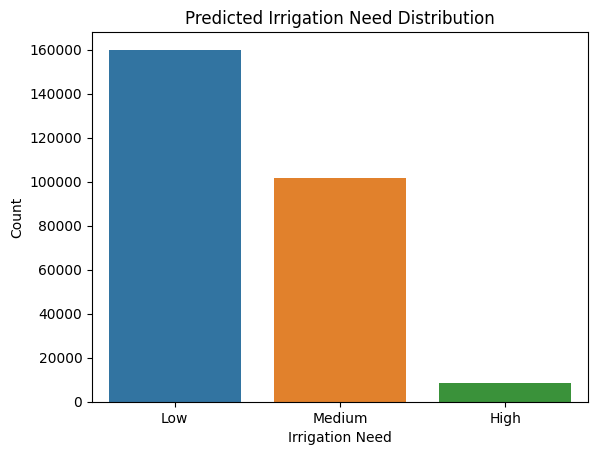

In [66]:
#plotting our test file predictions
sns.countplot(x=test_predictions, hue=test_predictions)
plt.title("Predicted Irrigation Need Distribution")
plt.xlabel("Irrigation Need")
plt.ylabel("Count")
plt.show()

## 6. Submission Output 

In [67]:
bagging_submission = pd.DataFrame({
    "id": test_file["id"],
    "Irrigation_Need": test_predictions
})
bagging_submission.head(20)

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


In [68]:
bagging_submission.to_csv("Advanced_ML_Work/Git_Code/Kaggle Homework Lucas lucascalaff206/bagging_submission.csv", index=False)